# 03 — Treino da U-Net

Treina a U-Net clássica (Ronneberger et al., 2015) nas imagens pré-processadas.

Todos os hiperparâmetros são lidos do `config.yaml`. 
Funções auxiliares de treino (checkpoints, loaders, avaliação) vêm de `src/utils.py`.


In [1]:
import sys
import os
from pathlib import Path

# Muda para a raiz do projeto (2 níveis acima do notebook)
notebook_dir = Path.cwd()
project_root = notebook_dir.parent.parent
os.chdir(project_root)

sys.path.insert(0, str(project_root / 'skin_lesion'))

import yaml
import torch
import torch.nn as nn
import torch.optim as optim
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt

from src.models.unet import UNet
from src.utils import (
    get_loaders,
    save_checkpoint,
    load_checkpoint,
    check_accuracy,
    save_predictions_as_imgs,
)

with open('config.yaml') as f:
    cfg = yaml.safe_load(f)

tcfg   = cfg['training']
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
print(f'Working directory: {os.getcwd()}')
print(yaml.dump(cfg['training'], allow_unicode=True))


Device: cuda
Working directory: c:\Users\lucas\UFERSA\Computer_Science\IC\Segmentation
augmentation:
  horizontal_flip_p: 0.5
  rotate_limit: 35
  vertical_flip_p: 0.1
batch_size: 8
checkpoint_dir: skin_lesion/results/checkpoints
early_stopping_patience: 25
features:
- 64
- 128
- 256
- 512
- 1024
in_channels: 3
learning_rate: 0.0001
num_epochs: 100
num_workers: 2
out_channels: 1
pin_memory: true
train_image_dir: skin_lesion/data/processed/training/images
train_mask_dir: skin_lesion/data/processed/training/masks
val_image_dir: skin_lesion/data/processed/validation/images
val_mask_dir: skin_lesion/data/processed/validation/masks



## 1. Transforms (Data Augmentation)


In [2]:
aug = tcfg['augmentation']
h   = cfg['preprocessing']['resize']['height']
w   = cfg['preprocessing']['resize']['width']

# Treino: augmentation + normalização ImageNet
train_transform = A.Compose([
    A.Resize(height=h, width=w),
    A.Rotate(limit=aug['rotate_limit'], p=1.0),
    A.HorizontalFlip(p=aug['horizontal_flip_p']),
    A.VerticalFlip(p=aug['vertical_flip_p']),
    A.Normalize(mean=[0.0, 0.0, 0.0], std=[1.0, 1.0, 1.0], max_pixel_value=255.0),
    ToTensorV2(),
])

# Validação: só normalização (sem augmentation)
val_transform = A.Compose([
    A.Resize(height=h, width=w),
    A.Normalize(mean=[0.0, 0.0, 0.0], std=[1.0, 1.0, 1.0], max_pixel_value=255.0),
    ToTensorV2(),
])


## 2. DataLoaders


In [3]:
# get_loaders instancia SkinLesionDataset e DataLoader para treino e val
train_loader, val_loader = get_loaders(
    train_dir=tcfg['train_image_dir'],
    train_maskdir=tcfg['train_mask_dir'],
    val_dir=tcfg['val_image_dir'],
    val_maskdir=tcfg['val_mask_dir'],
    batch_size=tcfg['batch_size'],
    train_transform=train_transform,
    val_transform=val_transform,
    num_workers=tcfg['num_workers'],
    pin_memory=tcfg['pin_memory'],
)

print(f'Treino : {len(train_loader.dataset)} imagens | {len(train_loader)} batches')
print(f'Val    : {len(val_loader.dataset)} imagens | {len(val_loader)} batches')


Treino : 2594 imagens | 325 batches
Val    : 100 imagens | 13 batches


## 3. Modelo, Loss e Otimizador


In [4]:
model     = UNet(
    in_channels=tcfg['in_channels'],
    out_channels=tcfg['out_channels'],
    features=tcfg['features'],
).to(DEVICE)
loss_fn   = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=tcfg['learning_rate'])
scaler    = torch.cuda.amp.GradScaler()

# Carrega checkpoint se existir
ckpt_dir  = Path(tcfg['checkpoint_dir'])
ckpt_dir.mkdir(parents=True, exist_ok=True)
ckpt_path = ckpt_dir / 'unet_5blocks.pth'

start_epoch = 1
best_dice   = 0.0

if ckpt_path.exists():
    state       = load_checkpoint(ckpt_path, model, optimizer)
    start_epoch = state.get('epoch', 1) + 1
    best_dice   = state.get('val_dice', 0.0)
    print(f'Retomando do epoch {start_epoch} | melhor Dice até agora: {best_dice:.4f}')
else:
    print('Nenhum checkpoint encontrado — iniciando do zero.')

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parâmetros treináveis: {total_params:,}')


Nenhum checkpoint encontrado — iniciando do zero.
Parâmetros treináveis: 124,374,209


C:\Users\lucas\AppData\Local\Temp\ipykernel_5204\669517435.py:8: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = torch.cuda.amp.GradScaler()


## 4. Função de Treino


In [5]:
def train_epoch(loader, model, optimizer, loss_fn, scaler):
    """Roda uma época de treino e retorna a loss média."""
    model.train()
    total_loss = 0.0
    loop = tqdm(loader, desc='Treino', leave=False)

    for images, masks in loop:
        images = images.to(DEVICE)
        masks  = masks.unsqueeze(1).to(DEVICE)  # (B,H,W) → (B,1,H,W)

        with torch.cuda.amp.autocast():
            preds = model(images)
            loss  = loss_fn(preds, masks)

        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    return total_loss / len(loader)


## 5. Visualização do Data Augmentation

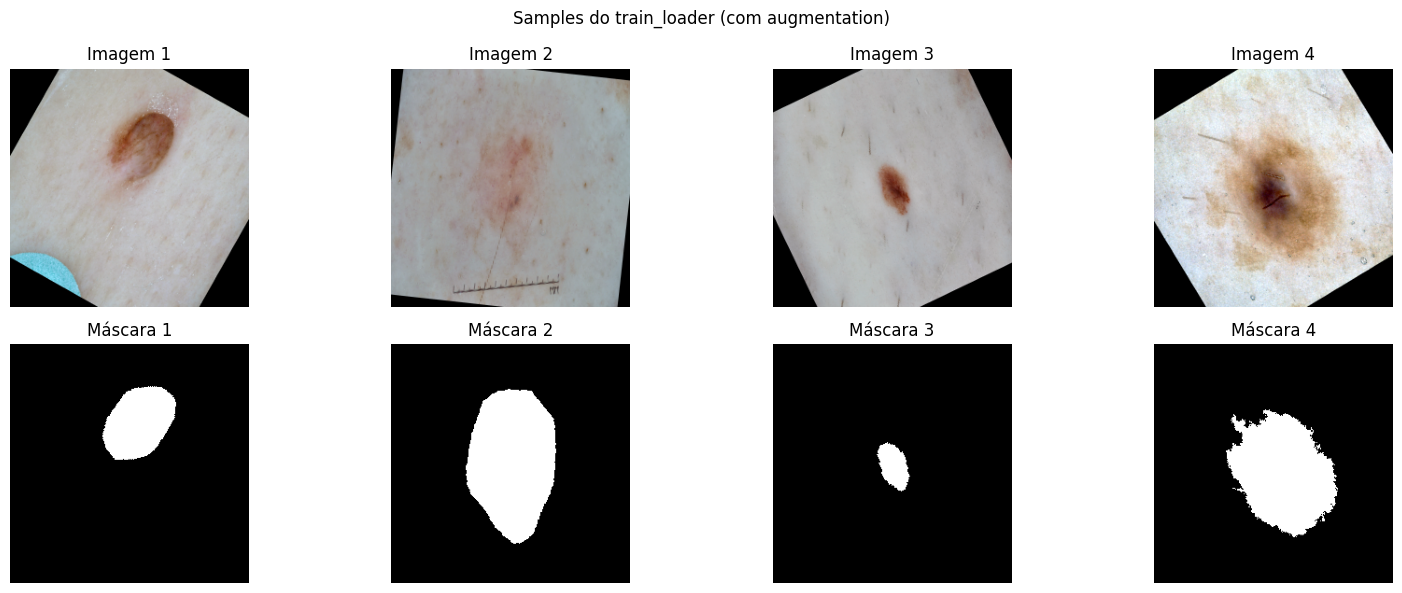

In [6]:
import torchvision
import matplotlib.pyplot as plt

images, masks = next(iter(train_loader))

# Mostra os primeiros 4 pares do batch
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
for i in range(4):
    axes[0, i].imshow(images[i].permute(1, 2, 0).cpu())
    axes[0, i].set_title(f'Imagem {i+1}')
    axes[0, i].axis('off')
    axes[1, i].imshow(masks[i].cpu(), cmap='gray')
    axes[1, i].set_title(f'Máscara {i+1}')
    axes[1, i].axis('off')

plt.suptitle('Samples do train_loader (com augmentation)')
plt.tight_layout()
plt.show()

## 6. Loop de Treino


In [6]:
history      = []
patience      = tcfg.get('early_stopping_patience', 20)
epochs_no_imp = 0  # contador de épocas sem melhora

for epoch in range(start_epoch, tcfg['num_epochs'] + 1):
    train_loss = train_epoch(train_loader, model, optimizer, loss_fn, scaler)
    metrics    = check_accuracy(val_loader, model, device=DEVICE)

    history.append({
        'epoch':      epoch,
        'train_loss': round(train_loss,         6),
        'val_acc':    round(metrics['accuracy'], 4),
        'val_dice':   round(metrics['dice'],     4),
    })

    if metrics['dice'] > best_dice:
        best_dice     = metrics['dice']
        epochs_no_imp = 0  # resetar contador
        save_checkpoint(
            state={
                'epoch':      epoch,
                'state_dict': model.state_dict(),
                'optimizer':  optimizer.state_dict(),
                'val_dice':   best_dice,
            },
            filepath=ckpt_path,
        )
    else:
        epochs_no_imp += 1
        if epochs_no_imp >= patience:
            print(f'\nEarly stopping: {patience} épocas sem melhora no Dice. '
                  f'Melhor Dice: {best_dice:.4f} (epoch {epoch - patience})')
            break

    print(f'Epoch {epoch:03d}/{tcfg["num_epochs"]} | '
          f'train_loss={train_loss:.4f} | '
          f'acc={metrics["accuracy"]:.4f} | '
          f'Dice={metrics["dice"]:.4f} | '
          f'sem melhora: {epochs_no_imp}/{patience}')

df_history = pd.DataFrame(history)
df_history.to_csv('skin_lesion/results/metrics/training_history_5blocks.csv', index=False)
print(f'\nTreino concluído. Melhor Dice: {best_dice:.4f}')

Treino:   0%|          | 0/325 [00:00<?, ?it/s]C:\Users\lucas\AppData\Local\Temp\ipykernel_5204\3799833418.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Acurácia : 5925215/6553600 (0.9041)
Dice     : 0.8005
=> Salvando checkpoint (epoch 1, Dice=0.8005)...
Epoch 001/100 | train_loss=0.3687 | acc=0.9041 | Dice=0.8005 | sem melhora: 0/25


Acurácia : 5921482/6553600 (0.9035)
Dice     : 0.7978
Epoch 002/100 | train_loss=0.2675 | acc=0.9035 | Dice=0.7978 | sem melhora: 1/25


Acurácia : 5986713/6553600 (0.9135)
Dice     : 0.8279
=> Salvando checkpoint (epoch 3, Dice=0.8279)...
Epoch 003/100 | train_loss=0.2241 | acc=0.9135 | Dice=0.8279 | sem melhora: 0/25


Acurácia : 6044319/6553600 (0.9223)
Dice     : 0.8448
=> Salvando checkpoint (epoch 4, Dice=0.8448)...
Epoch 004/100 | train_loss=0.1995 | acc=0.9223 | Dice=0.8448 | sem melhora: 0/25


...

Acurácia : 6186541/6553600 (0.9440)
Dice     : 0.8955
Epoch 037/100 | train_loss=0.0921 | acc=0.9440 | Dice=0.8955 | sem melhora: 21/25


Acurácia : 6153990/6553600 (0.9390)
Dice     : 0.8882
Epoch 038/100 | train_loss=0.0958 | acc=0.9390 | Dice=0.8882 | sem melhora: 22/25


Acurácia : 6163599/6553600 (0.9405)
Dice     : 0.8861
Epoch 039/100 | train_loss=0.0950 | acc=0.9405 | Dice=0.8861 | sem melhora: 23/25


Acurácia : 6155766/6553600 (0.9393)
Dice     : 0.8851
Epoch 040/100 | train_loss=0.0929 | acc=0.9393 | Dice=0.8851 | sem melhora: 24/25


Acurácia : 6133908/6553600 (0.9360)
Dice     : 0.8801

Early stopping: 25 épocas sem melhora no Dice. Melhor Dice: 0.8957 (epoch 16)

Treino concluído. Melhor Dice: 0.8957


## 7. Salvar Predições e Inspecionar Resultados

Carrega o melhor checkpoint e salva pares pred/ground-truth como PNG.


In [7]:
# Carrega o melhor checkpoint para gerar as predições finais
load_checkpoint(ckpt_path, model)

# save_predictions_as_imgs salva pred_{idx}.png e true_{idx}.png
save_predictions_as_imgs(
    loader=val_loader,
    model=model,
    folder='skin_lesion/results/saved_images/5blocks',
    device=DEVICE,
)
print('Predições salvas em results/saved_images/5blocks')

=> Carregando checkpoint: skin_lesion\results\checkpoints\unet_5blocks.pth
Predições salvas em results/saved_images/5blocks


## 8. Curvas de Aprendizado


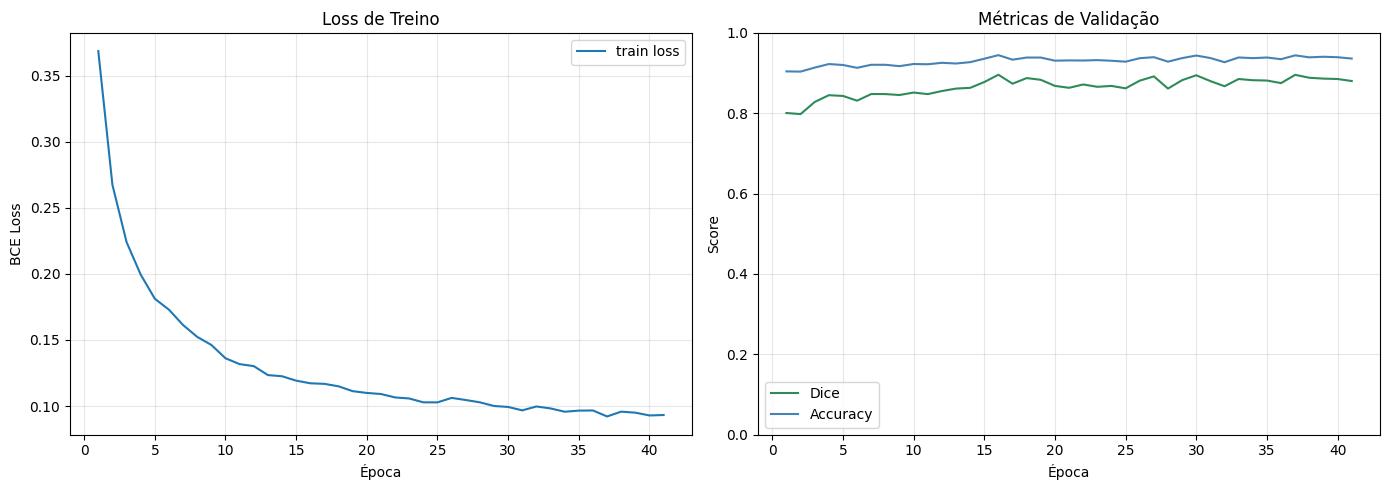

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(df_history['epoch'], df_history['train_loss'], label='train loss')
ax1.set(xlabel='Época', ylabel='BCE Loss', title='Loss de Treino')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(df_history['epoch'], df_history['val_dice'], label='Dice', color='seagreen')
ax2.plot(df_history['epoch'], df_history['val_acc'],  label='Accuracy', color='steelblue')
ax2.set(xlabel='Época', ylabel='Score', title='Métricas de Validação')
ax2.set_ylim(0, 1); ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('skin_lesion/results/figures/training_curves_5blocks.png', dpi=150)
plt.show()
